
=== Local Sensitivity Indices ===
Parameter  Sensitivity Index
        β           1.000000
        σ           0.000500
        γ          -0.908265
        μ          -0.001408
        ω          -0.090827


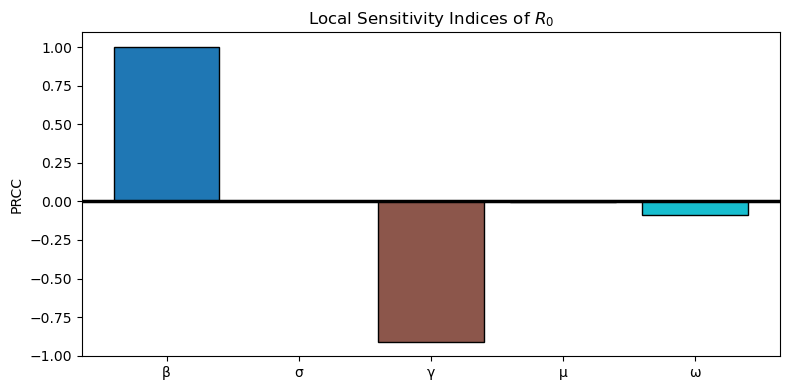


=== PRCC vs R0 ===
[ 0.96987639 -0.01543187 -0.96137204  0.02465267 -0.28199351]


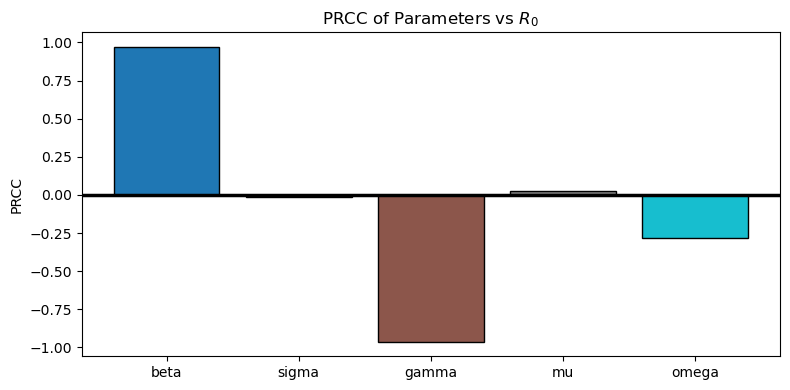


=== PRCC vs Peak Infected ===
[ 0.94071992  0.8260685  -0.97044661 -0.04044241 -0.33602291]


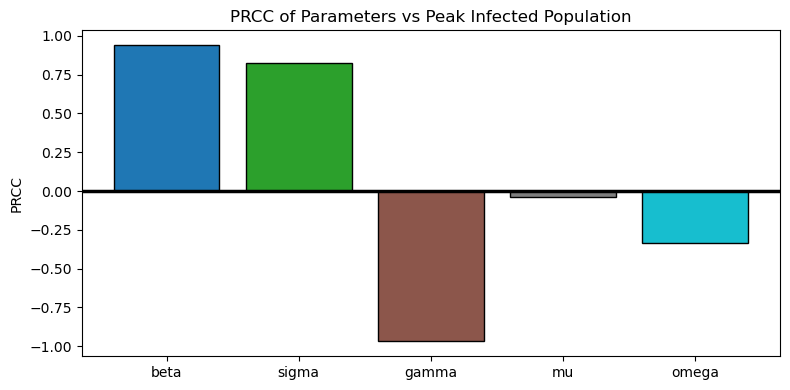

In [1]:
# ==========================================================
# Heat–SEIR Model Sensitivity Analysis (Improved Visualization)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.stats import qmc
from scipy import stats
import pandas as pd

# -----------------------------
# 1. R0 and Sensitivity Functions
# -----------------------------

def R0_formula(beta, sigma, gamma, mu, omega):
    return (beta * sigma) / ((sigma + mu) * (gamma + mu + omega))

def local_sensitivity_indices(beta, sigma, gamma, mu, omega):
    return {
        'Parameter': ['β', 'σ', 'γ',
                      'μ', 'ω'],
        'Sensitivity Index': [
            1.0,
            1.0 - sigma / (sigma + mu),
            -gamma / (gamma + mu + omega),
            -mu / (sigma + mu) - mu / (gamma + mu + omega),
            -omega / (gamma + mu + omega)
        ]
    }

# -----------------------------
# 2. Heat-SEIR Model
# -----------------------------

def heat_seir(y, t, N, Lambda, mu, sigma, gamma, omega, beta):
    S, E, I, R = y
    return (
        Lambda - beta * S * I / N - mu * S,
        beta * S * I / N - (sigma + mu) * E,
        sigma * E - (gamma + mu + omega) * I,
        gamma * I - mu * R
    )

def simulate_peak_infected(params, y0, t):
    beta, sigma, gamma, mu, omega, N, Lambda = params
    sol = odeint(heat_seir, y0, t, args=(N, Lambda, mu, sigma, gamma, omega, beta))
    I = sol[:, 2]
    return I.max()

# -----------------------------
# Helper: Pretty Bar Plot
# -----------------------------

def colored_bar_plot(labels, values, title):
    colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(labels, values, color=colors, edgecolor='black')

    # ZERO reference line (important requirement)
    ax.axhline(0, color='black', linewidth=2.5)

    # Highlight zero-value bars
    for bar, val in zip(bars, values):
        if np.isclose(val, 0.0):
            bar.set_edgecolor('black')
            bar.set_linewidth(2.5)

    ax.set_title(title)
    ax.set_ylabel("PRCC")
#    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=0, ha='center')
    plt.tight_layout()
    plt.show()

# -----------------------------
# 3. Parameters
# -----------------------------

base_params = {
    'beta': 0.5,
    'sigma': 0.2,
    'gamma': 0.1,
    'mu': 0.0001,
    'omega': 0.01
}

variation = 0.3
param_names = list(base_params.keys())
bounds = [(v*(1-variation), v*(1+variation)) for v in base_params.values()]

# -----------------------------
# 4. Local Sensitivity
# -----------------------------

lsi = local_sensitivity_indices(**base_params)
df_lsi = pd.DataFrame(lsi)

print("\n=== Local Sensitivity Indices ===")
print(df_lsi.to_string(index=False))

colored_bar_plot(
    df_lsi['Parameter'],
    df_lsi['Sensitivity Index'],
    "Local Sensitivity Indices of $R_0$"
)

# -----------------------------
# 5. Sampling
# -----------------------------

n_samples = 500
sampler = qmc.LatinHypercube(d=len(param_names), seed=42)
samples = qmc.scale(
    sampler.random(n_samples),
    [b[0] for b in bounds],
    [b[1] for b in bounds]
)

N = 1_000_000
Lambda = base_params['mu'] * N
y0 = (N - 10, 5, 5, 0)
t = np.linspace(0, 200, 200)

R0_vals = np.zeros(n_samples)
peakI_vals = np.zeros(n_samples)

for i, s in enumerate(samples):
    beta, sigma, gamma, mu, omega = s
    R0_vals[i] = R0_formula(beta, sigma, gamma, mu, omega)
    peakI_vals[i] = simulate_peak_infected(
        (beta, sigma, gamma, mu, omega, N, Lambda),
        y0, t
    )

# rank transform
ranks = np.apply_along_axis(stats.rankdata, 0, samples)
ranks_R0 = stats.rankdata(R0_vals)
ranks_peakI = stats.rankdata(peakI_vals)

# -----------------------------
# 6. PRCC function
# -----------------------------

def compute_prcc(X, Y):
    n_params = X.shape[1]
    prcc = np.zeros(n_params)

    for i in range(n_params):
        Xi = X[:, i]
        Xrest = np.delete(X, i, axis=1)

        X_design = np.hstack([Xrest, np.ones((Xrest.shape[0], 1))])

        beta_i, *_ = np.linalg.lstsq(X_design, Xi, rcond=None)
        ri = Xi - X_design @ beta_i

        beta_y, *_ = np.linalg.lstsq(X_design, Y, rcond=None)
        ry = Y - X_design @ beta_y

        prcc[i] = stats.pearsonr(ri, ry)[0]

    return prcc

prcc_R0 = compute_prcc(ranks, ranks_R0)
prcc_peakI = compute_prcc(ranks, ranks_peakI)

# -----------------------------
# 7. Results + Colored Plots
# -----------------------------

print("\n=== PRCC vs R0 ===")
print(prcc_R0)

colored_bar_plot(
    param_names,
    prcc_R0,
    "PRCC of Parameters vs $R_0$"
)

print("\n=== PRCC vs Peak Infected ===")
print(prcc_peakI)

colored_bar_plot(
    param_names,
    prcc_peakI,
    "PRCC of Parameters vs Peak Infected Population"
)


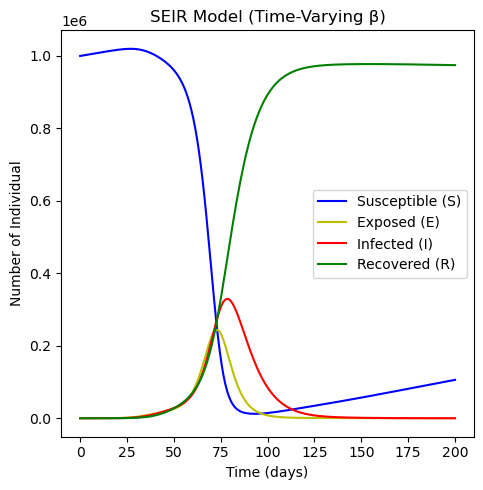

In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Parameters
N = 1_000_000   # population
Lambda = 1000   # recruitment rate
mu = 0.0001     # natural mortality
sigma = 0.2     # latent progression
gamma = 0.1     # recovery
omega = 0.01    # heat-related mortality
beta_const = 0.5  # constant beta

# SEIR model equations
def deriv(y, t, N, Lambda, mu, sigma, gamma, omega, beta_func):
    S, E, I, R = y
    beta = beta_func(t)
    dSdt = Lambda - beta * S * I / N - mu * S
    dEdt = beta * S * I / N - (sigma + mu) * E
    dIdt = sigma * E - (gamma + mu + omega) * I
    dRdt = gamma * I - mu * R
    return dSdt, dEdt, dIdt, dRdt

# Initial conditions
S0, E0, I0, R0 = N-10, 5, 5, 0
y0 = S0, E0, I0, R0

# Time grid
t = np.linspace(0, 200, 200)

# Case 1: constant beta
beta_func_const = lambda t: beta_const
sol_const = odeint(deriv, y0, t, args=(N, Lambda, mu, sigma, gamma, omega, beta_func_const))
S_c, E_c, I_c, R_c = sol_const.T

# Case 2: time-varying beta
beta_func_time = lambda t: 0.5 * (1 + 0.5 * np.sin(0.1*t))
sol_time = odeint(deriv, y0, t, args=(N, Lambda, mu, sigma, gamma, omega, beta_func_time))
S_t, E_t, I_t, R_t = sol_time.T
beta_values = [beta_func_time(tt) for tt in t]  # store beta over time

# --- Plotting ---
plt.figure(figsize=(14,5))

# Time-varying beta case
plt.subplot(1,3,2)
plt.plot(t, S_t, 'b', label='Susceptible (S)')
plt.plot(t, E_t, 'y', label='Exposed (E)')
plt.plot(t, I_t, 'r', label='Infected (I)')
plt.plot(t, R_t, 'g', label='Recovered (R)')
plt.title("SEIR Model (Time-Varying β)")
plt.xlabel("Time (days)")
plt.ylabel("Number of Individual")
plt.legend()
plt.gca().set_aspect('auto')


plt.tight_layout()
plt.show()